In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
df = pd.read_csv('bi.csv', encoding = 'latin1')
df.head()

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
0,Christina,Binger,44,Female,Norway,Private,72,Masters,158,59.0,55
1,Alex,Walekhwa,60,M,Kenya,Private,79,Diploma,150,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,HighSchool,130,74.0,50
3,Shoni,Hlongwane,22,F,Rsa,Sognsvann,40,High School,120,NaN,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,122,91.0,80


In [42]:
df.columns


Index(['fNAME', 'lNAME', 'Age', 'gender', 'country', 'residence', 'entryEXAM',
       'prevEducation', 'studyHOURS', 'Python', 'DB'],
      dtype='object')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fNAME          77 non-null     object 
 1   lNAME          77 non-null     object 
 2   Age            77 non-null     int64  
 3   gender         77 non-null     object 
 4   country        77 non-null     object 
 5   residence      77 non-null     object 
 6   entryEXAM      77 non-null     int64  
 7   prevEducation  77 non-null     object 
 8   studyHOURS     77 non-null     int64  
 9   Python         75 non-null     float64
 10  DB             77 non-null     int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 6.7+ KB


In [44]:
df.describe(include = 'all')

,fNAME,lNAME,Age,gender,country,residence,entryEXAM,prevEducation,studyHOURS,Python,DB
count,77,77,77.000000,77,77,77,77.000000,77,77.000000,75.000000,77.000000
unique,71,66,NaN,6,16,6,NaN,10,NaN,NaN,NaN
top,Grethe,Olsen,NaN,Female,Norway,Private,NaN,Bachelors,NaN,NaN,NaN
freq,2,2,NaN,41,47,33,NaN,24,NaN,NaN,NaN
mean,NaN,NaN,35.207792,NaN,NaN,NaN,76.753247,NaN,149.714286,75.853333,69.467532
std,NaN,NaN,10.341966,NaN,NaN,NaN,16.475784,NaN,12.743272,15.410328,17.033701
min,NaN,NaN,21.000000,NaN,NaN,NaN,28.000000,NaN,114.000000,15.000000,30.000000
25%,NaN,NaN,27.000000,NaN,NaN,NaN,69.000000,NaN,144.000000,71.000000,56.000000
50%,NaN,NaN,33.000000,NaN,NaN,NaN,80.000000,NaN,156.000000,81.000000,71.000000
75%,NaN,NaN,42.000000,NaN,NaN,NaN,90.000000,NaN,158.000000,85.000000,83.000000


In [45]:
cols =['fNAME', 'lNAME', 'Age', 'gender', 'country', 'residence', 'entryEXAM',
       'prevEducation', 'studyHOURS', 'Python', 'DB']

df.columns = [col.strip().lower() for col in cols]
df.columns

Index(['fname', 'lname', 'age', 'gender', 'country', 'residence', 'entryexam',
       'preveducation', 'studyhours', 'python', 'db'],
      dtype='object')

In [46]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


In [47]:
print("Jumlah missing values:", "\n", df.isnull().sum())

Jumlah missing values: 
 fname            0
lname            0
age              0
gender           0
country          0
residence        0
entryexam        0
preveducation    0
studyhours       0
python           2
db               0
dtype: int64


In [48]:
df['gender'].unique()

array(['Female', 'M', 'Male', 'F', 'female', 'male'], dtype=object)

In [49]:
df['gender'] = df['gender'].str.strip().str.title()

gender = {'M':'Male', 'F': 'Female'}
df['gender'] = df['gender'].replace(gender)
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [50]:
df['country'].unique()

array(['Norway', 'Kenya', 'Uganda', 'Rsa', 'South Africa', 'Norge',
       'norway', 'Denmark', 'Netherlands', 'Italy', 'Spain', 'UK',
       'Somali', 'Nigeria', 'Germany', 'France'], dtype=object)

In [51]:
df['country'] = df['country'].str.strip().str.title().replace({'Rsa':'South Africa', 'Uk': 'United Kingdom', 'Norge': 'Norway'})
df['country'].unique()



array(['Norway', 'Kenya', 'Uganda', 'South Africa', 'Denmark',
       'Netherlands', 'Italy', 'Spain', 'United Kingdom', 'Somali',
       'Nigeria', 'Germany', 'France'], dtype=object)

In [52]:
df['python'] = df['python'].fillna(df['python'].median())
df.isnull().sum()

fname            0
lname            0
age              0
gender           0
country          0
residence        0
entryexam        0
preveducation    0
studyhours       0
python           0
db               0
dtype: int64

In [53]:
df['preveducation'].unique()

array(['Masters', 'Diploma', 'HighSchool', 'High School', 'Bachelors',
       'Barrrchelors', 'diploma', 'DIPLOMA', 'Diplomaaa', 'Doctorate'],
      dtype=object)

In [54]:
df['preveducation'] = df['preveducation'].str.strip().str.title().replace({'Highschool':'High School', 'Diplomaaa' : 'Diploma', 'Barrrchelors':'Bachelors'})
df['preveducation'].unique()

array(['Masters', 'Diploma', 'High School', 'Bachelors', 'Doctorate'],
      dtype=object)

In [55]:
df['studyhours'] = (df['studyhours']/60).round(2)
df.head()

,fname,lname,age,gender,country,residence,entryexam,preveducation,studyhours,python,db
0,Christina,Binger,44,Female,Norway,Private,72,Masters,2.63,59.0,55
1,Alex,Walekhwa,60,Male,Kenya,Private,79,Diploma,2.50,60.0,75
2,Philip,Leo,25,Male,Uganda,Sognsvann,55,High School,2.17,74.0,50
3,Shoni,Hlongwane,22,Female,South Africa,Sognsvann,40,High School,2.00,81.0,44
4,Maria,Kedibone,23,Female,South Africa,Sognsvann,65,High School,2.03,91.0,80


In [56]:
df['residence'].unique()

array(['Private', 'Sognsvann', 'BI Residence', 'BI-Residence',
       'BIResidence', 'BI_Residence'], dtype=object)

In [57]:
# Mencari kata yang diawali 'BI' dan diakhiri 'Residence' dengan karakter pemisah apa pun
df['residence'] = df['residence'].str.replace(r'BI.*Residence', 'BI Residence', regex=True)

# Rapikan spasi di awal/akhir jika ada
df['residence'] = df['residence'].str.strip()

df['residence'].unique()

array(['Private', 'Sognsvann', 'BI Residence'], dtype=object)

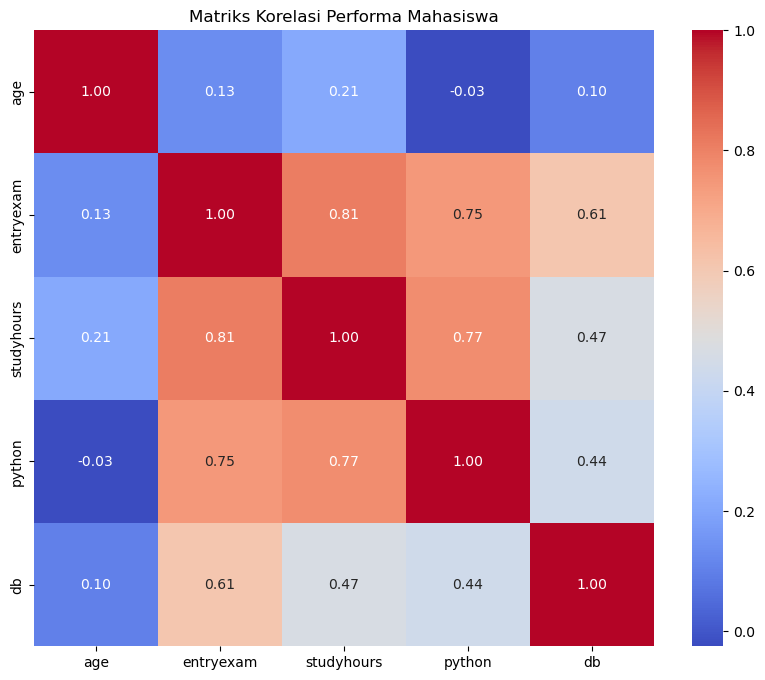

In [58]:
#Mengambil kolom numerik saja
df_numeric = df.select_dtypes(include=['number'])

#Menghitung korelasi
corr = df_numeric.corr()

#Menampilkan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Performa Mahasiswa')
plt.show()

In [59]:
df.to_csv("bi_clean.csv")